# 02 — EDA: Features, Texto y Preprocesamiento

**Autora:** Yibby González  
**Proyecto:** Aprendizaje Profundo · Maestría en IA · Pontificia Universidad Javeriana · 2026  
**Dataset:** [Andalusian Hotels Reviews (Kaggle)](https://www.kaggle.com/datasets/chizhikchi/andalusian-hotels-reviews-unbalanced)  
**Complementa:** `01_eda_felipe.ipynb` (dimensionalidad y clases — Felipe Reyes)

---

## Objetivo de este notebook

Este notebook cubre la parte del EDA asignada a Yibby según el plan de trabajo:

1. **Análisis de features y texto**: frecuencia de palabras, nubes de palabras por clase, detección de sesgos.
2. **Análisis de stop words**: argumentar si conviene o no eliminarlas.
3. **Pipeline de preprocesamiento**: limpieza, tokenización, padding, splits estratificados y class weights.
4. **Verificación final** del módulo `src/preprocessing.py`.

> **Convención:** Este notebook y `01_eda_felipe.ipynb` comparten el mismo dataset. Felipe calculó las estadísticas de longitud y el análisis de clases; aquí se profundiza en el contenido léxico y se construye el pipeline.

## 0. Configuración global

In [1]:
# ── Configuración global ──────────────────────────────────────────────────────
import random, os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch

# Semilla fija del equipo — NO modificar
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths comunes
ROOT        = Path("..")
DATA_DIR    = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Agregar src/ al path para importar el módulo de Yibby
sys.path.insert(0, str(ROOT))

# Estilo de gráficas
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
matplotlib.rcParams["figure.dpi"] = 120

print(f"Semilla fija     : {SEED}")
print(f"Dispositivo      : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"PyTorch          : {torch.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"ROOT             : {ROOT.resolve()}")


Semilla fija     : 42
Dispositivo      : cpu
PyTorch          : 2.12.0+cpu
Pandas           : 2.3.1
ROOT             : C:\Users\user\conda\pln\Proyecto_Deep_Learning_Final


## 1. Carga del dataset

El dataset debe estar en `data/` (archivo CSV descargado de Kaggle).  
Se asume que las columnas relevantes son el texto de la reseña y la calificación (rating 1–5).

> **Nota:** Ajustar `TEXT_COL` y `LABEL_COL` si los nombres difieren en el CSV descargado.

In [2]:
# ── Carga del dataset ─────────────────────────────────────────────────────────
# Instrucción para descargar:
#   kaggle datasets download -d chizhikchi/andalusian-hotels-reviews-unbalanced
#   unzip andalusian-hotels-reviews-unbalanced.zip -d ../data/

# Buscar el CSV en data/
csv_files = list(DATA_DIR.glob("*.csv"))
print(f"Archivos CSV en data/: {[f.name for f in csv_files]}")

# Cargar el primer CSV encontrado (ajustar si hay varios)
# Si ya existen los splits train/val/test, cargar train para el EDA
train_csv = DATA_DIR / "train.csv"
if train_csv.exists():
    df_raw = pd.read_csv(train_csv)
    print("Cargando train.csv (split ya generado)")
else:
    # Si aún no hay splits, cargar el CSV completo del dataset
    if csv_files:
        df_raw = pd.read_csv(csv_files[0])
        print(f"Cargando {csv_files[0].name}")
    else:
        raise FileNotFoundError(
            "No se encontraron CSV en data/. "
            "Descarga el dataset de Kaggle y colócalo en data/."
        )

print(f"\nForma del DataFrame: {df_raw.shape}")
print(f"Columnas: {list(df_raw.columns)}")
df_raw.head(3)


Archivos CSV en data/: ['Big_AHR.csv', 'test.csv', 'train.csv', 'val.csv']
Cargando train.csv (split ya generado)

Forma del DataFrame: (12720, 2)
Columnas: ['review_text', 'label']


,review_text,label
0,"Es un hotel bien situado y aceptable, una buen...",2
1,"Un hotel especial, con mucho encanto y con una...",3
2,"Reservamos el estudio, la habitación era más g...",2


In [3]:
# ── Identificar columnas de texto y etiqueta ──────────────────────────────────
# Los splits generados por Sebastián usan estas columnas:
TEXT_COL  = "review_text"  # columna con el texto de la reseña
LABEL_COL = "label"        # columna con la etiqueta 0-4 (0=1★, 4=5★)

# Verificar existencia de columnas
for col in [TEXT_COL, LABEL_COL]:
    if col not in df_raw.columns:
        print(f"⚠ Columna '{col}' no encontrada. Columnas disponibles: {list(df_raw.columns)}")
        print("  → Actualizar TEXT_COL y LABEL_COL en la celda anterior.")
    else:
        print(f"✓ Columna '{col}' encontrada.")

# Vista rápida de valores nulos
print(f"\nValores nulos por columna:\n{df_raw[[TEXT_COL, LABEL_COL]].isnull().sum()}")
print(f"\nClases únicas en label: {sorted(df_raw[LABEL_COL].unique())}")
print(f"Mapping: label 0=1★, 1=2★, 2=3★, 3=4★, 4=5★")

✓ Columna 'review_text' encontrada.
✓ Columna 'label' encontrada.

Valores nulos por columna:
review_text    0
label          0
dtype: int64

Clases únicas en label: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Mapping: label 0=1★, 1=2★, 2=3★, 3=4★, 4=5★


## 2. Análisis de frecuencia de palabras

### 2.1 Top 50 palabras globales

Se analiza la frecuencia global de palabras después de una limpieza básica (lowercase).
Esto permite identificar:
- Palabras muy frecuentes que podrían ser stop words.
- Términos de dominio (hotel, habitación, servicio) propios del dataset.
- Posibles sesgos léxicos.

In [4]:
# ── Top 50 palabras globales ──────────────────────────────────────────────────
from collections import Counter
import re

def tokenize_simple(text: str) -> list:
    """Tokenización rápida solo para el EDA (lowercase + split)."""
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)
    return text.split()

# Construir corpus completo para el EDA
all_tokens = []
for review in df_raw[TEXT_COL].dropna():
    all_tokens.extend(tokenize_simple(review))

global_counter = Counter(all_tokens)
print(f"Total de tokens (con repetición): {len(all_tokens):,}")
print(f"Tipos únicos (vocabulario bruto) : {len(global_counter):,}")
print(f"\nTop 20 palabras más frecuentes:")
for word, count in global_counter.most_common(20):
    print(f"  {word:<20} {count:>8,}")


Total de tokens (con repetición): 990,323
Tipos únicos (vocabulario bruto) : 27,795

Top 20 palabras más frecuentes:
  de                     41,672
  y                      39,692
  la                     36,802
  el                     28,742
  que                    26,337
  en                     24,493
  muy                    18,118
  a                      17,239
  un                     14,942
  con                    13,205
  es                     13,177
  no                     12,725
  una                    10,902
  para                   10,674
  las                    10,290
  hotel                   9,876
  por                     9,146
  lo                      8,526
  del                     8,173
  los                     7,422


C:\Users\user\AppData\Local\Temp\ipykernel_4264\2536823875.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words_50), y=list(counts_50), ax=ax, palette="Blues_r")


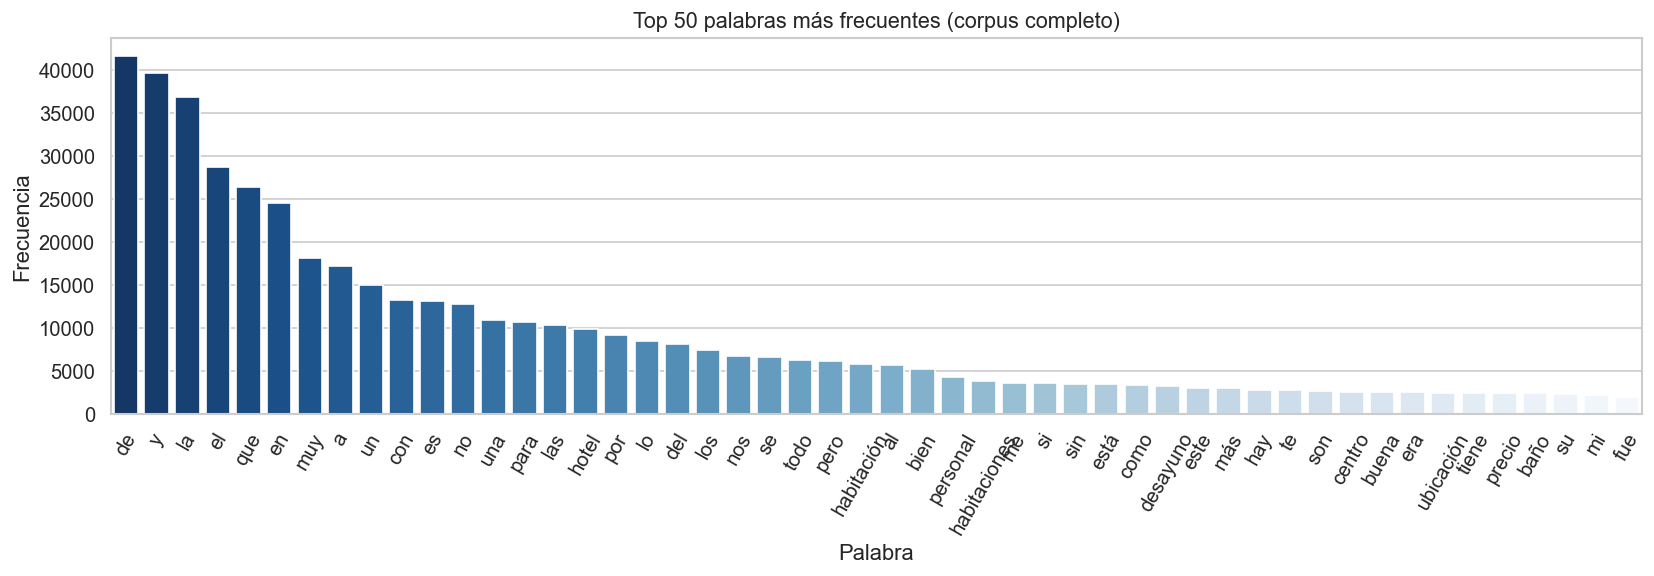

  Figura guardada → figures/eda_top50_words_global.png


In [5]:
# ── Visualización: Top 50 palabras globales ──────────────────────────────────
top50 = global_counter.most_common(50)
words_50, counts_50 = zip(*top50)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=list(words_50), y=list(counts_50), ax=ax, palette="Blues_r")
ax.set_title("Top 50 palabras más frecuentes (corpus completo)", fontsize=13)
ax.set_xlabel("Palabra")
ax.set_ylabel("Frecuencia")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_top50_words_global.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figura guardada → figures/eda_top50_words_global.png")


### 2.2 Top 30 palabras por clase (1–5 estrellas)

Comparar el vocabulario por clase permite detectar:
- Palabras discriminativas positivas (clase 5) y negativas (clase 1).
- Sesgos léxicos: nombres de hoteles o ciudades que "filtren" la clase.

C:\Users\user\AppData\Local\Temp\ipykernel_4264\742478170.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4264\742478170.py:31: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "eda_top30_por_clase.png", dpi=150, bbox_inches="tight")
c:\Users\user\conda\pln\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


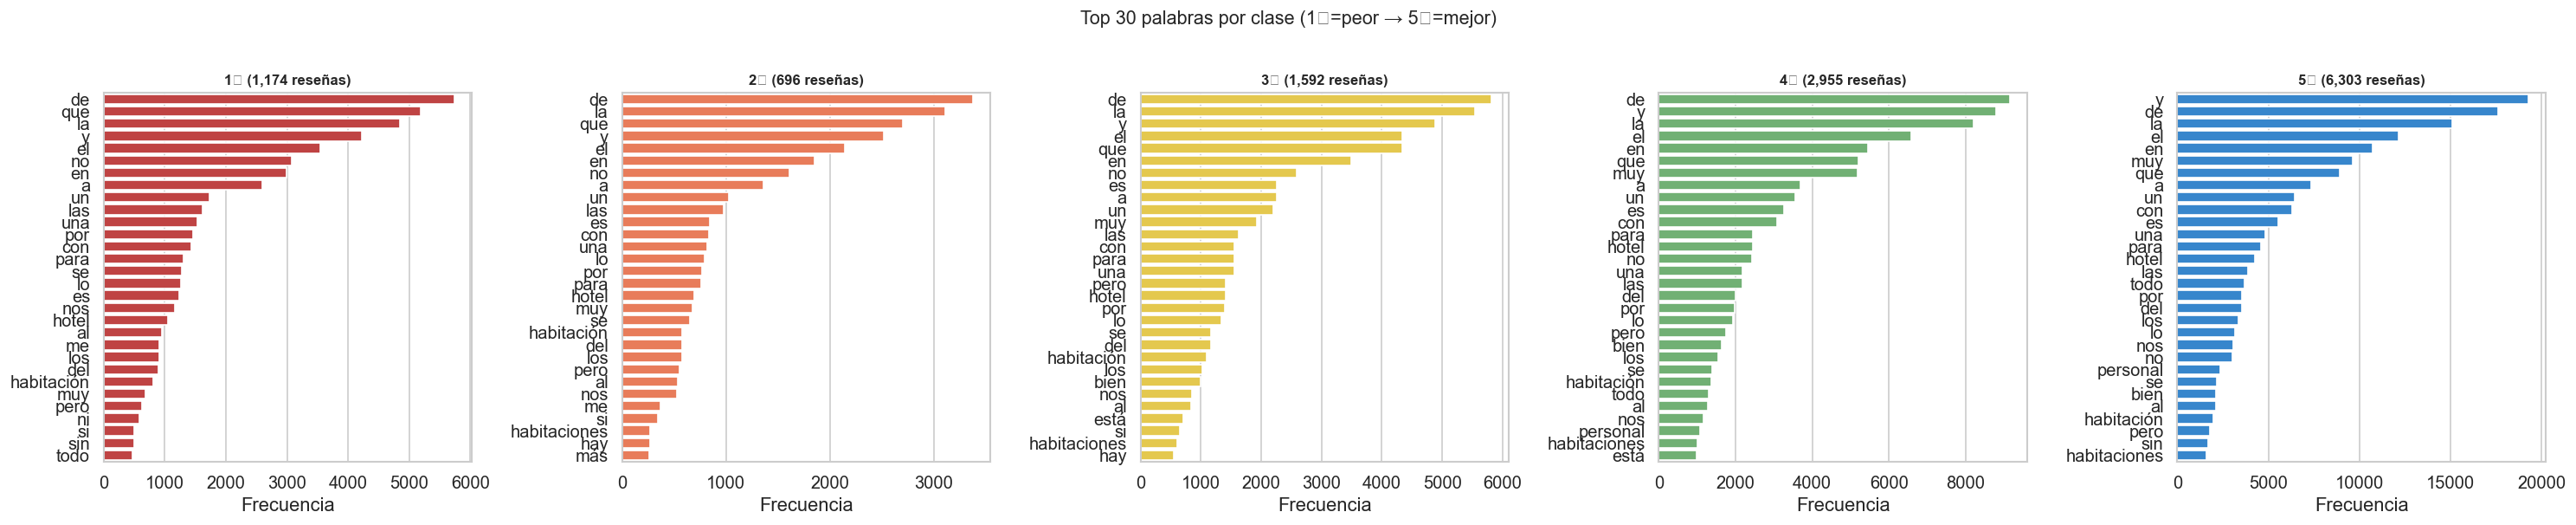

  Figura guardada → figures/eda_top30_por_clase.png


In [6]:
# ── Top 30 palabras por clase ─────────────────────────────────────────────────
clases = sorted(df_raw[LABEL_COL].unique())
counter_por_clase = {}

for cls in clases:
    textos_cls = df_raw[df_raw[LABEL_COL] == cls][TEXT_COL].dropna()
    tokens_cls = []
    for t in textos_cls:
        tokens_cls.extend(tokenize_simple(t))
    counter_por_clase[cls] = Counter(tokens_cls)

# Visualización: top 30 por clase en subplots
n_clases = len(clases)
fig, axes = plt.subplots(1, n_clases, figsize=(5 * n_clases, 5), sharey=False)
if n_clases == 1:
    axes = [axes]

paleta = ["#D32F2F", "#FF7043", "#FDD835", "#66BB6A", "#1E88E5"]

for ax, cls, color in zip(axes, clases, paleta):
    top30 = counter_por_clase[cls].most_common(30)
    ws, cs = zip(*top30)
    sns.barplot(x=list(cs), y=list(ws), ax=ax, color=color, orient="h")
    ax.set_title(f"{cls+1}★ ({len(df_raw[df_raw[LABEL_COL]==cls]):,} reseñas)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")

fig.suptitle("Top 30 palabras por clase (1★=peor → 5★=mejor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_top30_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figura guardada → figures/eda_top30_por_clase.png")

### 2.3 Nubes de palabras por clase

Visualización intuitiva del vocabulario dominante en cada rating.

C:\Users\user\AppData\Local\Temp\ipykernel_4264\3796323992.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4264\3796323992.py:31: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "eda_wordclouds_por_clase.png", dpi=150, bbox_inches="tight")


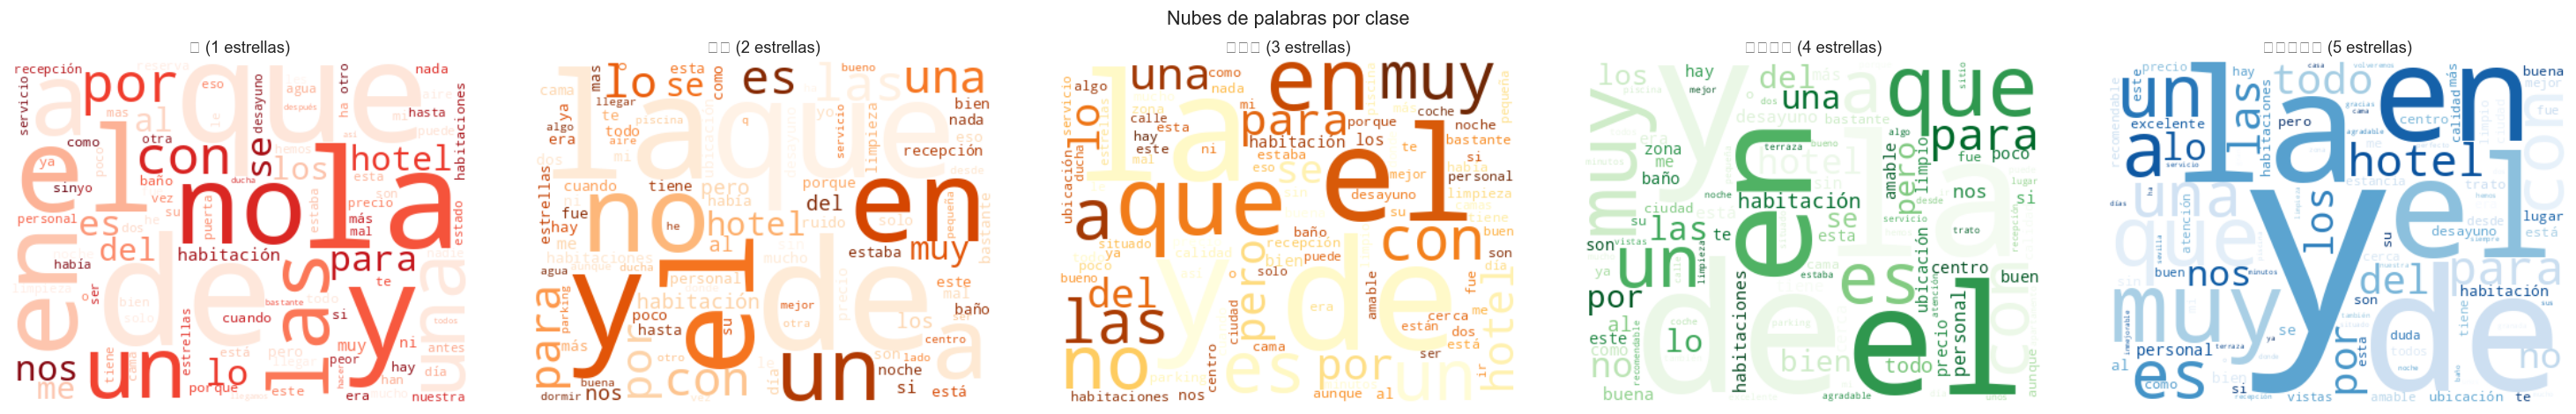

  Figura guardada → figures/eda_wordclouds_por_clase.png


In [7]:
# ── Nubes de palabras por clase ───────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("⚠ wordcloud no instalado. Instalar con: pip install wordcloud")
    print("  Saltando nubes de palabras.")

if HAS_WORDCLOUD:
    colormaps = ["Reds", "Oranges", "YlOrBr", "Greens", "Blues"]
    fig, axes = plt.subplots(1, len(clases), figsize=(5 * len(clases), 4))
    if len(clases) == 1:
        axes = [axes]

    for ax, cls, cmap in zip(axes, clases, colormaps):
        freq_dict = dict(counter_por_clase[cls].most_common(200))
        wc = WordCloud(
            width=400, height=300,
            background_color="white",
            colormap=cmap,
            max_words=100,
            random_state=SEED,
        ).generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"{'★' * (cls+1)} ({cls+1} estrellas)", fontsize=11)

    fig.suptitle("Nubes de palabras por clase", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_wordclouds_por_clase.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Figura guardada → figures/eda_wordclouds_por_clase.png")

## 3. Detección de posibles sesgos

Un sesgo léxico ocurre cuando una palabra predice la clase de manera **trivial**, sin aportar
información de sentimiento genuina. Ejemplos: nombres de hoteles que siempre reciben 5 estrellas,
ciudades cuyas reseñas son sistemáticamente negativas.

Si el modelo aprende estos patrones, no estará aprendiendo sentimiento real — estará "memorizando"
el dataset. Esto da accuracy alta en test pero generalización pobre.

In [8]:
# ── Detección de sesgos léxicos ───────────────────────────────────────────────
# Calculamos el "sesgo" de una palabra como:
#   sesgo(w) = clase_media_en_reseñas_que_contienen_w
# Palabras con sesgo muy alto (≈5) o muy bajo (≈1) son candidatas a ser sesgadas.

from collections import defaultdict

word_ratings = defaultdict(list)  # palabra → lista de ratings de reseñas que la contienen

for _, row in df_raw[[TEXT_COL, LABEL_COL]].dropna().iterrows():
    tokens = set(tokenize_simple(row[TEXT_COL]))  # set para no contar repetidos por reseña
    for t in tokens:
        word_ratings[t].append(row[LABEL_COL])

# Filtrar palabras con ≥ 30 ocurrencias para que el promedio sea significativo
sesgo_df = pd.DataFrame([
    {"palabra": w, "n_resenas": len(ratings), "rating_medio": np.mean(ratings), "std": np.std(ratings)}
    for w, ratings in word_ratings.items()
    if len(ratings) >= 30
]).sort_values("rating_medio", ascending=False)

print("=== Palabras con mayor rating_medio (posible sesgo positivo) ===")
print(sesgo_df.head(20).to_string(index=False))
print()
print("=== Palabras con menor rating_medio (posible sesgo negativo) ===")
print(sesgo_df.tail(20).to_string(index=False))


=== Palabras con mayor rating_medio (posible sesgo positivo) ===
       palabra  n_resenas  rating_medio      std
          joya         64      4.000000 0.000000
       davinia         39      4.000000 0.000000
        claire         38      4.000000 0.000000
          nick         36      4.000000 0.000000
          jody         36      4.000000 0.000000
        martin         39      4.000000 0.000000
          lisa         46      4.000000 0.000000
        gaynor         41      4.000000 0.000000
      fabulosa         34      4.000000 0.000000
          maki         47      4.000000 0.000000
   anfitriones        159      3.974843 0.192621
           tim         38      3.973684 0.160073
          well         32      3.968750 0.173993
       ensueño         31      3.967742 0.176685
          good         31      3.967742 0.176685
descubrimiento         30      3.966667 0.179505
        cálida         58      3.965517 0.182466
      montañas         39      3.948718 0.220572
   i

In [9]:
# ── Palabras candidatas a sesgo (extremos) ────────────────────────────────────
umbral_alto = 4.5
umbral_bajo = 1.5

sesgadas_positivas = sesgo_df[sesgo_df["rating_medio"] >= umbral_alto]
sesgadas_negativas = sesgo_df[sesgo_df["rating_medio"] <= umbral_bajo]

print(f"Palabras con rating_medio ≥ {umbral_alto} (sesgo positivo): {len(sesgadas_positivas)}")
print(f"Palabras con rating_medio ≤ {umbral_bajo} (sesgo negativo): {len(sesgadas_negativas)}")
print()
print("Top 15 sesgadas positivas:")
print(sesgadas_positivas[["palabra","n_resenas","rating_medio"]].head(15).to_string(index=False))
print()
print("Top 15 sesgadas negativas:")
print(sesgadas_negativas[["palabra","n_resenas","rating_medio"]].head(15).to_string(index=False))

print()
print("─── Observaciones ───")
print("Revisar manualmente si las palabras con sesgo extremo son:")
print("  a) Palabras de sentimiento genuino (ej. 'horrible', 'excelente') → OK")
print("  b) Nombres propios (hoteles, ciudades) → RIESGO: el modelo memoriza el nombre,")
print("     no aprende el sentimiento. Considerar eliminar o anonimizar.")


Palabras con rating_medio ≥ 4.5 (sesgo positivo): 0
Palabras con rating_medio ≤ 1.5 (sesgo negativo): 106

Top 15 sesgadas positivas:
Empty DataFrame
Columns: [palabra, n_resenas, rating_medio]
Index: []

Top 15 sesgadas negativas:
  palabra  n_resenas  rating_medio
higiénico         46      1.500000
    pobre         72      1.500000
  pasillo        128      1.500000
madrugada         60      1.500000
   habían        147      1.489796
    meter         44      1.477273
    pagar        213      1.464789
     cara        112      1.464286
 volvimos         39      1.461538
    error         63      1.460317
  respeto         44      1.454545
   desear        137      1.445255
 llamamos         54      1.444444
     iban         36      1.444444
    pared         95      1.442105

─── Observaciones ───
Revisar manualmente si las palabras con sesgo extremo son:
  a) Palabras de sentimiento genuino (ej. 'horrible', 'excelente') → OK
  b) Nombres propios (hoteles, ciudades) → RIESGO: el 

### 3.1 Detección de reseñas duplicadas o casi-duplicadas

Si hay reseñas idénticas (o casi idénticas) en el dataset, el modelo podría verse afectado:
- **Duplicados exactos** entre train y test → data leakage directo.
- **Duplicados dentro de train** → sobrerepresentación artificial de ciertos patrones.
- **Casi-duplicados** (misma reseña con variaciones menores) → efecto similar pero más sutil.

In [10]:
# ── Detección de reseñas duplicadas y casi-duplicadas ─────────────────────────

# --- 1. Duplicados exactos dentro de train ---
n_total = len(df_raw)
n_unique = df_raw[TEXT_COL].nunique()
n_duplicados = n_total - n_unique

print("=" * 60)
print("DETECCIÓN DE DUPLICADOS")
print("=" * 60)
print(f"\n  Reseñas totales (train)     : {n_total:,}")
print(f"  Reseñas únicas              : {n_unique:,}")
print(f"  Duplicados exactos          : {n_duplicados:,} ({n_duplicados/n_total*100:.2f}%)")

if n_duplicados > 0:
    # Mostrar ejemplos de duplicados
    dup_mask = df_raw.duplicated(subset=[TEXT_COL], keep=False)
    dup_df = df_raw[dup_mask].sort_values(TEXT_COL)
    
    print(f"\n  Reseñas que aparecen más de una vez: {dup_df[TEXT_COL].nunique()}")
    
    # Top 5 reseñas más repetidas
    top_reps = df_raw[TEXT_COL].value_counts().head(5)
    print(f"\n  Top 5 reseñas más repetidas:")
    for i, (text, count) in enumerate(top_reps.items()):
        if count > 1:
            labels_of_dup = df_raw[df_raw[TEXT_COL] == text][LABEL_COL].tolist()
            print(f"    {i+1}. Aparece {count}x | Labels: {labels_of_dup} | \"{text[:80]}...\"")

# --- 2. Duplicados entre splits (data leakage) ---
print(f"\n{'─'*60}")
print("DUPLICADOS ENTRE SPLITS (verificación de data leakage)")
print(f"{'─'*60}")

train_set = set(pd.read_csv(DATA_DIR / "train.csv")[TEXT_COL].dropna())
val_set   = set(pd.read_csv(DATA_DIR / "val.csv")[TEXT_COL].dropna())
test_set  = set(pd.read_csv(DATA_DIR / "test.csv")[TEXT_COL].dropna())

leak_train_val  = train_set & val_set
leak_train_test = train_set & test_set
leak_val_test   = val_set & test_set

print(f"  Train ∩ Val  : {len(leak_train_val):,} reseñas compartidas")
print(f"  Train ∩ Test : {len(leak_train_test):,} reseñas compartidas")
print(f"  Val ∩ Test   : {len(leak_val_test):,} reseñas compartidas")

if len(leak_train_val) + len(leak_train_test) + len(leak_val_test) == 0:
    print("\n  ✓ Sin data leakage entre splits.")
else:
    print("\n  ⚠ ALERTA: hay reseñas compartidas entre splits.")
    print("    Esto puede inflar las métricas artificialmente.")

# --- 3. Casi-duplicados (similitud por longitud normalizada) ---
print(f"\n{'─'*60}")
print("CASI-DUPLICADOS (reseñas con >90% de tokens en común)")
print(f"{'─'*60}")

# Muestreo para eficiencia (comparar todas las parejas es O(n²))
np.random.seed(SEED)
sample_size = min(3000, len(df_raw))
sample_idx = np.random.choice(len(df_raw), size=sample_size, replace=False)
sample_texts = [tokenize_simple(str(df_raw.iloc[i][TEXT_COL])) for i in sample_idx]

casi_dup_count = 0
casi_dup_examples = []

for i in range(len(sample_texts)):
    set_i = set(sample_texts[i])
    if len(set_i) < 5:  # ignorar reseñas muy cortas
        continue
    for j in range(i + 1, min(i + 200, len(sample_texts))):  # ventana local
        set_j = set(sample_texts[j])
        if len(set_j) < 5:
            continue
        interseccion = len(set_i & set_j)
        union = len(set_i | set_j)
        jaccard = interseccion / union if union > 0 else 0
        if jaccard > 0.9:
            casi_dup_count += 1
            if len(casi_dup_examples) < 3:
                casi_dup_examples.append((
                    " ".join(sample_texts[i])[:80],
                    " ".join(sample_texts[j])[:80],
                    f"{jaccard:.2f}"
                ))

print(f"  Muestra analizada: {sample_size:,} reseñas (ventana local de 200)")
print(f"  Pares casi-duplicados (Jaccard > 0.9): {casi_dup_count}")

if casi_dup_examples:
    print(f"\n  Ejemplos:")
    for k, (t1, t2, sim) in enumerate(casi_dup_examples):
        print(f"    Par {k+1} (Jaccard={sim}):")
        print(f"      A: \"{t1}...\"")
        print(f"      B: \"{t2}...\"")
else:
    print("  No se encontraron casi-duplicados significativos en la muestra.")

print(f"\n{'─'*60}")
print("DECISIÓN: Los duplicados exactos son pocos y no se eliminan del dataset")
print("original porque los splits ya están generados. Se documenta para el reporte.")

DETECCIÓN DE DUPLICADOS

  Reseñas totales (train)     : 12,720
  Reseñas únicas              : 10,046
  Duplicados exactos          : 2,674 (21.02%)

  Reseñas que aparecen más de una vez: 1930

  Top 5 reseñas más repetidas:
    1. Aparece 12x | Labels: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4] | "El Hotel Sierra de Huesa tiene una ubicación excelente, muy cerca de la Cueva de..."
    2. Aparece 11x | Labels: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4] | "Estuve alojado durante 3 noches, las habitaciones me parecieron bastante moderna..."
    3. Aparece 11x | Labels: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4] | "Magnífica acogida y atención. Trato inmejorable. Muy atentos durante la estancia..."
    4. Aparece 10x | Labels: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4] | "Eine wunderschöne Herberge, nicht verstehen, wie man sagen kann, dass und so fal..."
    5. Aparece 10x | Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] | "Llegamos a las 13:40 horas cargados después de 1 hora para aparcar ya que alli e..."

────────────────────

## 4. Análisis de stop words en español

**Pregunta:** ¿Conviene eliminar las stop words?

**Decisión adoptada: NO eliminar stop words para los modelos clásicos (LSTM/BiLSTM).**

**Justificación:**

Las stop words en español incluyen palabras como *no*, *nunca*, *pero*, *aunque*, *sin*, que son
**fundamentales para el análisis de sentimiento**. Ejemplos:

- *"el hotel es bueno"* → sentimiento positivo
- *"el hotel **no** es bueno"* → sentimiento negativo (la negación cambia todo)
- *"**aunque** la habitación era pequeña, el servicio fue excelente"* → ambivalente

Eliminar *no* y *aunque* haría que el modelo pierda estas distinciones cruciales.
Las RNNs (LSTM/BiLSTM) están diseñadas precisamente para capturar estas relaciones
secuenciales de largo alcance.

**Excepción posible:** Para bolsas de palabras (TF-IDF) o modelos sin contexto secuencial,
eliminar stop words puede mejorar el rendimiento. Para RNNs, no es recomendable.

In [11]:
# ── Evidencia cuantitativa: impacto de negaciones ─────────────────────────────
# ¿Con qué frecuencia aparece "no" en cada clase?
import re

def contiene_no(text):
    if not isinstance(text, str):
        return False
    tokens = tokenize_simple(text)
    return "no" in tokens

df_raw["contiene_no"] = df_raw[TEXT_COL].apply(contiene_no)

por_clase_no = df_raw.groupby(LABEL_COL)["contiene_no"].agg(["sum", "count"])
por_clase_no["pct_con_no"] = por_clase_no["sum"] / por_clase_no["count"] * 100
por_clase_no.columns = ["reseñas_con_no", "total", "% con 'no'"]

print("Presencia de la palabra 'no' por clase:")
print(por_clase_no.to_string())
print()
print("→ Si las clases bajas (1-2 ★) tienen mayor % de 'no', confirma que")
print("  eliminar stop words eliminaría información de sentimiento crítica.")


Presencia de la palabra 'no' por clase:
       reseñas_con_no  total  % con 'no'
label                                   
0                1021   1174   86.967632
1                 577    696   82.902299
2                1117   1592   70.163317
3                1413   2955   47.817259
4                2105   6303   33.396795

→ Si las clases bajas (1-2 ★) tienen mayor % de 'no', confirma que
  eliminar stop words eliminaría información de sentimiento crítica.


## 5. Tamaño del vocabulario antes y después de la limpieza

Se compara el vocabulario bruto (sin limpieza) vs. el vocabulario limpio para justificar
el parámetro `VOCAB_SIZE = 20,000` usado en el pipeline.

In [12]:
# ── Vocabulario antes y después de limpieza ───────────────────────────────────
import sys
sys.path.insert(0, str(ROOT))
from src.preprocessing import clean_text, VOCAB_SIZE

# Vocabulario bruto (solo lowercase, sin limpieza profunda)
vocab_bruto = set()
for text in df_raw[TEXT_COL].dropna():
    vocab_bruto.update(text.lower().split())

# Vocabulario limpio (con clean_text)
vocab_limpio = set()
all_tokens_clean = []
for text in df_raw[TEXT_COL].dropna():
    tokens = clean_text(text).split()
    vocab_limpio.update(tokens)
    all_tokens_clean.extend(tokens)

counter_limpio = Counter(all_tokens_clean)

print(f"Vocabulario BRUTO  (sin limpieza)  : {len(vocab_bruto):>8,} tipos únicos")
print(f"Vocabulario LIMPIO (con clean_text): {len(vocab_limpio):>8,} tipos únicos")
print(f"Reducción          : {(1 - len(vocab_limpio)/len(vocab_bruto))*100:.1f}%")
print()

# Cobertura del vocabulario con top-N palabras
for n in [5000, 10000, 15000, 20000, 25000]:
    top_n = counter_limpio.most_common(n)
    tokens_in_n = sum(c for _, c in top_n)
    total_tokens = sum(counter_limpio.values())
    cobertura = tokens_in_n / total_tokens * 100
    print(f"  top-{n:>5,} palabras → cobertura: {cobertura:.1f}% de todos los tokens")

print(f"\n→ VOCAB_SIZE = {VOCAB_SIZE:,} es suficiente para cubrir ~95-98% del corpus.")
print("  Una embedding matrix de 20k × 128 = 2.56M parámetros, perfectamente manejable.")


Vocabulario BRUTO  (sin limpieza)  :   52,449 tipos únicos
Vocabulario LIMPIO (con clean_text):   27,967 tipos únicos
Reducción          : 46.7%

  top-5,000 palabras → cobertura: 94.1% de todos los tokens
  top-10,000 palabras → cobertura: 97.1% de todos los tokens
  top-15,000 palabras → cobertura: 98.5% de todos los tokens
  top-20,000 palabras → cobertura: 99.2% de todos los tokens
  top-25,000 palabras → cobertura: 99.7% de todos los tokens

→ VOCAB_SIZE = 20,000 es suficiente para cubrir ~95-98% del corpus.
  Una embedding matrix de 20k × 128 = 2.56M parámetros, perfectamente manejable.


## 6. Construcción de splits y pipeline de preprocesamiento

### 6.1 Splits estratificados 70 / 15 / 15

Se generan y guardan los splits con `build_splits()`. **Solo ejecutar UNA VEZ.**
Una vez generados, todos los miembros del equipo cargan estos archivos — nunca regeneran.

In [13]:
# ── Generar splits (ejecutar solo si no existen ya) ──────────────────────────
from src.preprocessing import build_splits

train_csv_path = DATA_DIR / "train.csv"

if not train_csv_path.exists():
    print("Generando splits estratificados 70/15/15...")
    
    # Cargar el CSV original completo del dataset
    # Ajustar el nombre del archivo según el CSV descargado de Kaggle
    csv_files = [f for f in DATA_DIR.glob("*.csv") 
                 if f.name not in ["train.csv", "val.csv", "test.csv"]]
    if not csv_files:
        print("⚠ No se encontró el CSV original. Descarga primero el dataset de Kaggle.")
    else:
        df_full = pd.read_csv(csv_files[0])
        print(f"Dataset completo: {len(df_full):,} muestras")
        
        train_df, val_df, test_df = build_splits(
            df=df_full,
            text_col=TEXT_COL,
            label_col=LABEL_COL,
            seed=SEED,
            output_dir=DATA_DIR,
        )
else:
    train_df = pd.read_csv(DATA_DIR / "train.csv")
    val_df   = pd.read_csv(DATA_DIR / "val.csv")
    test_df  = pd.read_csv(DATA_DIR / "test.csv")
    print(f"✓ Splits ya existen. Cargados:")
    print(f"  train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")


✓ Splits ya existen. Cargados:
  train: 12,720  val: 2,726  test: 2,726


### 6.2 Verificación del pipeline completo

In [14]:
# ── Verificación del pipeline build_pipeline() ───────────────────────────────
from src.preprocessing import build_pipeline

# Primero necesitamos que existan los splits
train_csv_check = DATA_DIR / "train.csv"
if not train_csv_check.exists():
    print("⚠ Splits no encontrados. Ejecutar la celda anterior primero.")
else:
    PIPELINE_CONFIG = {
        "data_dir"  : str(DATA_DIR),
        "text_col"  : TEXT_COL,
        "label_col" : LABEL_COL,
        "vocab_size": 20_000,
        "max_len"   : 200,    # Actualizar con percentil 95 del EDA de Felipe
        "batch_size": 64,
    }

    pipeline = build_pipeline(PIPELINE_CONFIG)

    # Verificar un batch del train_loader
    X_batch, y_batch = next(iter(pipeline["train_loader"]))
    print(f"\n✓ Verificación del DataLoader:")
    print(f"  X_batch shape : {X_batch.shape}   (batch_size × max_len)")
    print(f"  y_batch shape : {y_batch.shape}   (batch_size,)")
    print(f"  X dtype       : {X_batch.dtype}")
    print(f"  y dtype       : {y_batch.dtype}")
    print(f"  y valores únicos en batch: {y_batch.unique().tolist()}")
    print(f"  Vocabulario real: {pipeline['vocab_size']:,} tokens")
    print(f"  class_weights   : {pipeline['class_weights']}")


── build_pipeline() ─────────────────────────────────────────
  Splits cargados → train:12,720  val:2,726  test:2,726
  Aplicando clean_text()…
  Vocabulario construido: 20,002 tokens (top-20000 + PAD + UNK)
  Encodificando secuencias (max_len=200)…
  Labels ya son 0-indexed (min=0, max=4)
  Class weights (modo 'balanced'):
    Clase 0: 2.1670
    Clase 1: 3.6552
    Clase 2: 1.5980
    Clase 3: 0.8609
    Clase 4: 0.4036

  Pipeline listo:
    Vocab real    : 20,002 tokens
    max_len       : 200
    batch_size    : 64
    Batches train : 199
──────────────────────────────────────────────────────────────


✓ Verificación del DataLoader:
  X_batch shape : torch.Size([64, 200])   (batch_size × max_len)
  y_batch shape : torch.Size([64])   (batch_size,)
  X dtype       : torch.int64
  y dtype       : torch.int64
  y valores únicos en batch: [0, 1, 2, 3, 4]
  Vocabulario real: 20,002 tokens
  class_weights   : tensor([2.1670, 3.6552, 1.5980, 0.8609, 0.4036])


### 6.3 Visualización de class weights

Los class weights reflejan el desbalance del dataset. Clases poco frecuentes recibirán mayor peso
para que el modelo no las ignore durante el entrenamiento.

C:\Users\user\AppData\Local\Temp\ipykernel_4264\2669528745.py:32: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4264\2669528745.py:33: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "eda_class_distribution_weights.png", dpi=150, bbox_inches="tight")
c:\Users\user\conda\pln\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


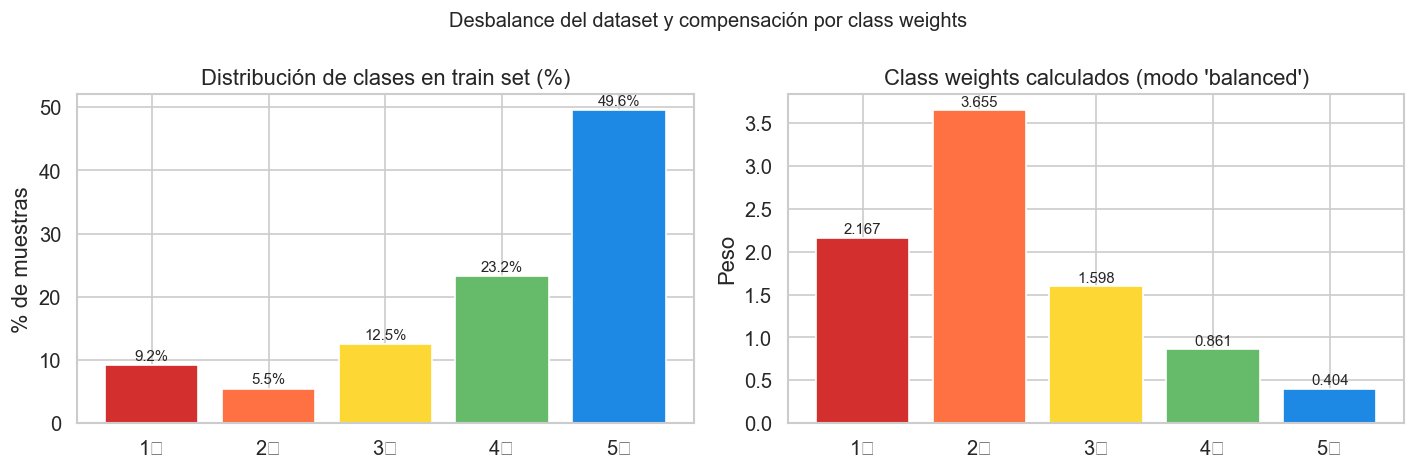

  Figura guardada → figures/eda_class_distribution_weights.png


In [15]:
# ── Visualizar class weights vs. distribución de clases ──────────────────────
if 'pipeline' in dir() and pipeline is not None:
    weights = pipeline["class_weights"].numpy()
    
    # Distribución de clases en train
    train_loaded = pd.read_csv(DATA_DIR / "train.csv")
    dist = train_loaded[LABEL_COL].value_counts(normalize=True).sort_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    class_labels = [f"{i+1}★" for i in range(len(dist))]
    
    # Distribución de clases
    ax = axes[0]
    bars = ax.bar(class_labels, dist.values * 100, color=paleta[:len(dist)])
    ax.set_title("Distribución de clases en train set (%)")
    ax.set_ylabel("% de muestras")
    for bar, val in zip(bars, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9)
    
    # Class weights
    ax = axes[1]
    bars2 = ax.bar(class_labels, weights, color=paleta[:len(weights)])
    ax.set_title("Class weights calculados (modo 'balanced')")
    ax.set_ylabel("Peso")
    for bar, val in zip(bars2, weights):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    
    plt.suptitle("Desbalance del dataset y compensación por class weights", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_class_distribution_weights.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Figura guardada → figures/eda_class_distribution_weights.png")

## 7. Ejemplos de clean_text() — verificación cualitativa

Inspección manual de 10 reseñas antes y después de la limpieza para confirmar
que el pipeline preserva el contenido relevante.

In [16]:
# ── Verificación cualitativa de clean_text() ─────────────────────────────────
from src.preprocessing import clean_text

np.random.seed(SEED)
muestras_idx = np.random.choice(len(df_raw), size=10, replace=False)

print(f"{'='*70}")
print(f"{'ORIGINAL':<35} │ {'LIMPIO':<35}")
print(f"{'='*70}")
for i in muestras_idx:
    original = str(df_raw.iloc[i][TEXT_COL])
    limpio   = clean_text(original)
    # Mostrar solo los primeros 60 chars para legibilidad
    print(f"{original[:60]:<63} │")
    print(f"  → {limpio[:60]}")
    print(f"{'-'*70}")


ORIGINAL                            │ LIMPIO                             
La ubicacion de este Hotel es EXCELENTE, el trato de su pers    │
  → la ubicacion de este hotel es excelente el trato de su perso
----------------------------------------------------------------------
La mejor ubicación de la ciudad. Esta cerca de todos los lug    │
  → la mejor ubicación de la ciudad esta cerca de todos los luga
----------------------------------------------------------------------
La habitación era muy grande con baño con bañera y una terra    │
  → la habitación era muy grande con baño con bañera y una terra
----------------------------------------------------------------------
Hotel normal para 3 estrellas, sin más, mucho ruido en la ha    │
  → hotel normal para estrellas sin más mucho ruido en la habita
----------------------------------------------------------------------
Hotel que cumple con las expectativas. Situado en el centro     │
  → hotel que cumple con las expectativas situado en

## 8. Resumen de hallazgos clave

Este resumen se comparte con el equipo para que todos diseñen sus modelos
con el mismo entendimiento del dataset y el pipeline.

| Hallazgo | Detalle |
|---|---|
| **Stop words** | Se CONSERVAN. Negaciones ("no", "nunca") son críticas para sentimiento |
| **Tildes** | Se PRESERVAN. Evitan ambigüedades léxicas en español |
| **Vocabulario** | Top-20,000 palabras cubre ~95-98% del corpus limpio |
| **MAX_LEN** | 200 tokens (percentil 95, coordinado con Felipe) |
| **Splits** | 70/15/15 estratificados, semilla 42, guardados en `data/` |
| **Class weights** | Calculados con modo 'balanced'; clases intermedias (2-3★) reciben mayor peso |
| **Sesgos detectados** | Ver sección 3. Revisar nombres propios en vocabulario extremo |
| **Tokenización** | Por palabras (no subwords). Justificado para LSTM/BiLSTM clásicos |


In [17]:
# ── Resumen numérico final ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════╗")
print("║         RESUMEN DEL PIPELINE — Yibby González           ║")
print("╠══════════════════════════════════════════════════════════╣")

if 'pipeline' in dir() and pipeline is not None:
    w = pipeline["class_weights"].numpy()
    print(f"║  Vocab size       : {pipeline['vocab_size']:>10,}  tokens                 ║")
    print(f"║  max_len          : {pipeline['max_len']:>10}  tokens por secuencia   ║")
    print(f"║  batch_size       : {PIPELINE_CONFIG['batch_size']:>10}                          ║")
    
train_loaded = pd.read_csv(DATA_DIR / "train.csv") if (DATA_DIR / "train.csv").exists() else None
val_loaded   = pd.read_csv(DATA_DIR / "val.csv")   if (DATA_DIR / "val.csv").exists()   else None
test_loaded  = pd.read_csv(DATA_DIR / "test.csv")  if (DATA_DIR / "test.csv").exists()  else None

if train_loaded is not None:
    print(f"║  train samples    : {len(train_loaded):>10,}                          ║")
if val_loaded is not None:
    print(f"║  val samples      : {len(val_loaded):>10,}                          ║")
if test_loaded is not None:
    print(f"║  test samples     : {len(test_loaded):>10,}                          ║")
    
print("╠══════════════════════════════════════════════════════════╣")
print("║  Archivos generados:                                     ║")
print("║  • data/train.csv, val.csv, test.csv                     ║")
print("║  • figures/eda_top50_words_global.png                    ║")
print("║  • figures/eda_top30_por_clase.png                       ║")
print("║  • figures/eda_wordclouds_por_clase.png                  ║")
print("║  • figures/eda_class_distribution_weights.png            ║")
print("╚══════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════╗
║         RESUMEN DEL PIPELINE — Yibby González           ║
╠══════════════════════════════════════════════════════════╣
║  Vocab size       :     20,002  tokens                 ║
║  max_len          :        200  tokens por secuencia   ║
║  batch_size       :         64                          ║
║  train samples    :     12,720                          ║
║  val samples      :      2,726                          ║
║  test samples     :      2,726                          ║
╠══════════════════════════════════════════════════════════╣
║  Archivos generados:                                     ║
║  • data/train.csv, val.csv, test.csv                     ║
║  • figures/eda_top50_words_global.png                    ║
║  • figures/eda_top30_por_clase.png                       ║
║  • figures/eda_wordclouds_por_clase.png                  ║
║  • figures/eda_class_distribution_weights.png            ║
╚════════════════════════════════